In [17]:
#IMPORTING LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#LOADING DATA
df = pd.read_csv('titanic.csv')

#VIEWING FIRST 5 ROWS
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
#CHECKING DATA TYPES AND MISSING VALUES
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
#CHECKING NUMBER OF ROWS AND COLUMNA
df.shape

(891, 12)

In [20]:
#LET'S SEE THE NUMERICAL COLUMNS
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
#CHECKING MISSING VALUES
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [22]:
#DATA CLEANING; ADDRESSING MISSING VALUES

df['Age'] = df['Age'].fillna(df['Age'].median())

In [23]:
#EMBARKED COLUMN

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [29]:
#CABIN, PASSENGERID, TICKET AND NAME COLUMNS

df= df.drop(columns=['Cabin', 'PassengerId', 'Ticket', 'Name'])

In [30]:
#CHECKING MISSING VALUES
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [31]:
#VIEWING FIRST 5 ROWS
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


(array([0, 1]), [Text(0, 0, 'Did Not Survive'), Text(1, 0, 'Survived')])

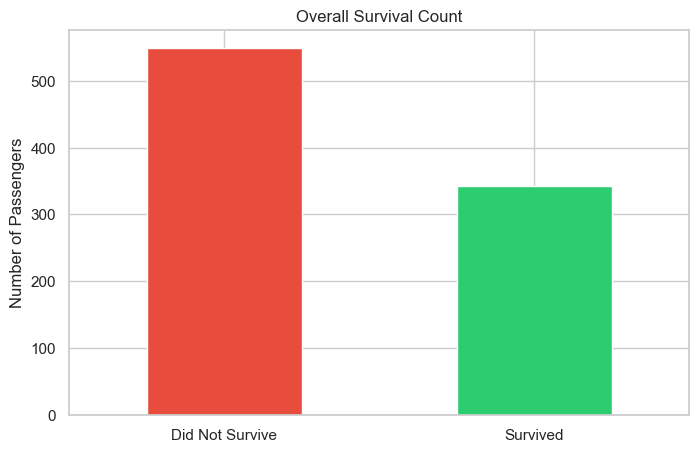

In [33]:
#VISUALIZATION

#SETTING CHART THEME
sns.set_theme(style="whitegrid")

#USING BAR CHART
plt.figure(figsize=(8, 5))
survival_counts = df_cleaned['Survived'].value_counts()
survival_counts.index = ['Did Not Survive', 'Survived']
survival_counts.plot(kind='bar', color=['#e74c3c', '#2ecc71'])

#NAMING
plt.title('Overall Survival Count')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)

Text(0.5, 1.0, 'Age Distribution of Passengers (Stacked by Survival)')

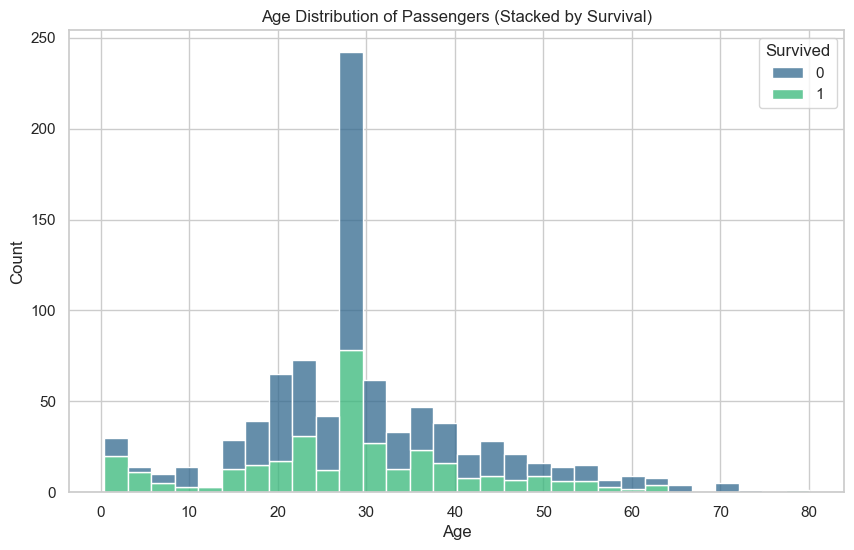

In [38]:
#ANALYZING AGE EFFECT

#USING A HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', palette='viridis', bins=30)
plt.title('Age Distribution of Passengers (Stacked by Survival)')

C:\Users\NEW\AppData\Local\Temp\ipykernel_37532\3636803360.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cleaned, x='Pclass', y='Survived', palette='Blues_d')


Text(0, 0.5, 'Survival Probability (0 to 1)')

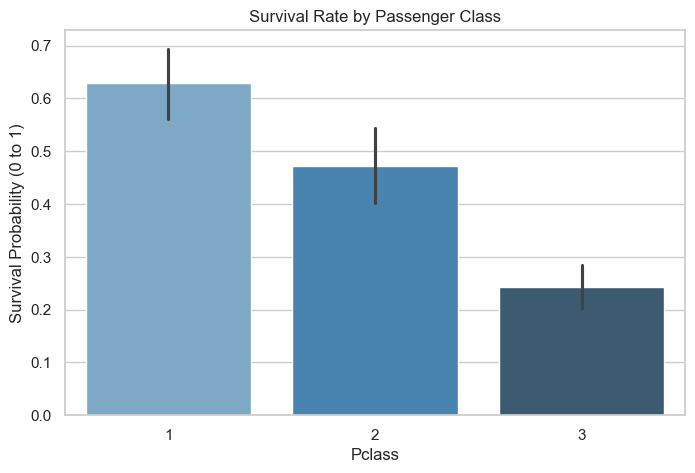

In [39]:
#LET'S SEE IF MONEY(WEALTH) OR CLASS MATTERS

# COMPARING SURVIVAL RATE ACROSS 1st, 2nd, and 3rd CLASS USING BAR CHART.
plt.figure(figsize=(8, 5))
sns.barplot(data=df_cleaned, x='Pclass', y='Survived', palette='Blues_d')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Probability (0 to 1)')